In [2]:
# This notebook produces results for CelebA experiments
%load_ext autoreload
%autoreload 2

from attack import TaskInference
import torch
import numpy as np
from data.vision import *
import torchvision.transforms as T

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

##### Download CelebA
https://drive.google.com/drive/folders/0B7EVK8r0v71pWEZsZE9oNnFzTm8?resourcekey=0-5BR16BdXnb8hVj6CNHKzLg

In [4]:
# Load and clean CelebA smiling classification data
data_dir = "/mnt/data/john/celeba/"
attributes_table = load_celeba_data(root=data_dir)

num_tasks=256
# Split data into IN/OUT
# Might want to save this for later use
in_df, out_df, in_ids, out_ids = generate_in_out_split_users_celeba(
    attributes_table, 
    num_members=num_tasks,
    save_dir="celeba-ckpt/"
)

# If you want to hold out data for the weak adversary, do it manually on attribute_table by 
# sampling from users in in_indices
holdout_examples = 8

holdout_sample = in_df.groupby('new_id').sample(n=holdout_examples, replace=False)
in_df = in_df.drop(holdout_sample.index)
holdout_sample = holdout_sample.reset_index(drop=True)
in_df = in_df.reset_index(drop=True)

# Create dataset objects
IMAGE_MEAN = (0.485, 0.456, 0.406)
IMAGE_STD = (0.229, 0.224, 0.225)
image_size = 64

in_dataset = CelebAMTLByUserMultiLabel(
        in_df, 
        root=data_dir, 
        samples_per_batch=16,
        transforms = T.Compose(
            [
                T.Resize((image_size, image_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(10, interpolation=T.InterpolationMode.BILINEAR),
                T.RandomCrop((image_size,image_size), padding=image_size//8, padding_mode="reflect"),
                T.ToTensor(),
                T.Normalize(
                    mean=IMAGE_MEAN,
                    std=IMAGE_STD
                ),
            ]
        )
    )

holdout_dataset = CelebAMTLByUserMultiLabel(
        holdout_sample, 
        root=data_dir, 
        samples_per_batch=holdout_examples,
        transforms = T.Compose(
            [
                T.Resize((image_size, image_size)),
                T.ToTensor(),
                T.Normalize(
                    mean=IMAGE_MEAN,
                    std=IMAGE_STD
                ),
            ]
        )
    )

out_dataset = CelebAMTLByUserMultiLabel(
        out_df, 
        root=data_dir,
        transforms = T.Compose(
            [
                T.Resize((image_size, image_size)),
                T.ToTensor(),
                T.Normalize(
                    mean=IMAGE_MEAN,
                    std=IMAGE_STD
                ),
            ]
        )
    )

print("Total Samples: ", len(in_df))

Total Samples:  5638


In [6]:
from models import MTLVision

mtl_model = MTLVision(num_tasks=num_tasks, num_classes=40, pretrained=True, arch="resnet34", bottleneck_dim=16)

print(mtl_model)

MTLVision(
  (shared_layers): Sequential(
    (0): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batc

In [7]:
from utils import train_mtl_vision_model

# Train model
accumulation_steps= 1
batch_size = 8 # Batches here are by user
num_workers = 8
in_dataloader = torch.utils.data.DataLoader(
    in_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

eval_dataloader = torch.utils.data.DataLoader(
    holdout_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

# Set epochs to a higher value (e.g. 500, 1000) depending on architecture as MTL can take a while to converge
epochs = 300

# Fix label imbalance
w = torch.FloatTensor(np.log(1/in_df[in_dataset.all_labels].mean()).to_numpy()).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=w)

# Recommended LR is on the order of 1e-4 - 1e-5. If possible, increase number of steps
optimizer = torch.optim.AdamW(
    [{"params": mtl_model.shared_layers.parameters(), "lr": 5e-4, "weight_decay": 1e-5,}] +
    [{"params": mtl_model.task_specific_layers[i].parameters(), "lr": 1e-3, "weight_decay": 1e-4,} for i in range(num_tasks)],
)

# Set learning rate schedule if needed
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-4)
# scheduler = None

trained_mtl_model, loss = train_mtl_vision_model(
        mtl_model,
        in_dataloader,
        epochs,
        criterion,
        optimizer,
        eval_loader=eval_dataloader, 
        scheduler=scheduler, 
        device=device, 
        multilabel=True, # Allow for multilabel classification
        eval_epochs=20, # Eval every X epochs
        eval_at_end=True, 
        ood_eval=False, # If True, do zero shot eval
        warm_start_epochs=int(epochs*0.2), # Number of epochs to freeze shared layers
        accumulation_steps=accumulation_steps # Gradient accumulation
    )
print("[Log] Final Loss: ", loss)

Testing...: 32it [00:00, 34.36it/s]0m| 0/300 [00:00<?, ?epoch/s]
Testing...: 32it [00:00, 36.44it/s]0m| 20/300 [00:31<06:55,  1.48s/epoch, loss=0.6965 || test loss=0.731]
Testing...: 32it [00:00, 36.48it/s]0m| 40/300 [01:02<06:23,  1.48s/epoch, loss=0.6096 || test loss=0.685]
Training...:  20%|██        | 60/300 [01:32<05:59,  1.50s/epoch, loss=0.4796 || test loss=0.574]

[Debug] Turning off warm start before epoch 61


Testing...: 32it [00:00, 35.70it/s]
Testing...: 32it [00:00, 35.84it/s]0m| 80/300 [02:28<09:52,  2.69s/epoch, loss=0.3941 || test loss=0.444]
Testing...: 32it [00:00, 34.46it/s]0m| 100/300 [03:24<09:17,  2.79s/epoch, loss=0.3487 || test loss=0.373]
Testing...: 32it [00:00, 36.38it/s]0m| 120/300 [04:20<08:08,  2.71s/epoch, loss=0.3108 || test loss=0.358]
Testing...: 32it [00:00, 34.91it/s]0m| 140/300 [05:17<07:23,  2.77s/epoch, loss=0.2658 || test loss=0.362]
Testing...: 32it [00:00, 35.74it/s]0m| 160/300 [06:14<06:29,  2.78s/epoch, loss=0.2301 || test loss=0.377]
Testing...: 32it [00:00, 34.25it/s]0m| 180/300 [07:10<05:29,  2.75s/epoch, loss=0.2047 || test loss=0.390]
Testing...: 32it [00:00, 35.17it/s]0m| 200/300 [08:06<04:36,  2.76s/epoch, loss=0.1878 || test loss=0.394]
Testing...: 32it [00:00, 34.30it/s]0m| 220/300 [09:02<03:43,  2.79s/epoch, loss=0.1730 || test loss=0.404]
Testing...: 32it [00:00, 35.76it/s]0m| 240/300 [09:59<02:43,  2.73s/epoch, loss=0.1676 || test loss=0.409]
Te

[Log] Final Loss:  0.4237241755181458


In [8]:
# Instantiate adversary
in_dataset._image_transforms = out_dataset._image_transforms
# print("[Debug] Ensure IN and OUT data have same transform", in_dataset._image_transforms, out_dataset._image_transforms)
adversary = TaskInference(trained_mtl_model, in_dataset, out_dataset)
weak_adversary = TaskInference(trained_mtl_model, holdout_dataset, out_dataset)

# Generate vision embeddings
adversary.generate_all_embeddings(device=device, whitening=True)
weak_adversary.generate_all_embeddings(device=device, whitening=True)

Generating OUT Embeddings...: 100%|██████████| 256/256 [00:06<00:00, 40.36task/s]


In [9]:
whitening = True
cosine = False

# Run coordinate-wise variance attack
test_statistic_variance, true_labels_variance = adversary.variance_attack(
    trials=128, 
    subsample=8,
    whitening=not whitening,
)

test_statistic_inner, true_labels_inner = adversary.inner_product_attack(
    trials=128,
    subsample=8,
    normalize=cosine,
    whitening=whitening
)

weak_test_statistic_variance, weak_true_labels_variance = weak_adversary.variance_attack(
    trials=128, 
    subsample=4,
    whitening=not whitening,
)

weak_test_statistic_inner, weak_true_labels_inner = weak_adversary.inner_product_attack(
    trials=128,
    subsample=4,
    normalize=cosine,
    whitening=whitening,
)

Running Inner Product Attack...:   2%|▏         | 3/128 [00:00<00:04, 27.45trial/s]

[Debug] Subsampling size:  8


Running Inner Product Attack...:   2%|▏         | 3/128 [00:00<00:04, 28.95trial/s]

[Debug] Subsampling size:  4


Running Inner Product Attack...: 100%|██████████| 128/128 [00:04<00:00, 28.74trial/s]


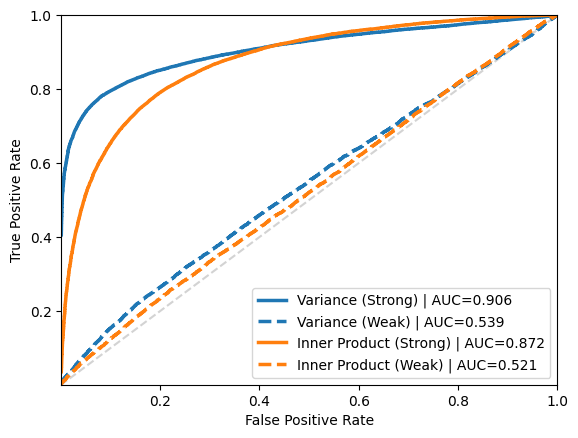

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Analyze results
fpr_v, tpr_v, thresh_v = roc_curve(true_labels_variance, test_statistic_variance)
auc_score_v = roc_auc_score(true_labels_variance, test_statistic_variance)

fpr_i, tpr_i, thresh_i = roc_curve(true_labels_inner, test_statistic_inner)
auc_score_i = roc_auc_score(true_labels_inner, test_statistic_inner)

# Analyze for weak adversary
fpr_v_weak, tpr_v_weak, thresh_v_weak = roc_curve(weak_true_labels_variance, weak_test_statistic_variance)
auc_score_v_weak = roc_auc_score(weak_true_labels_variance, weak_test_statistic_variance)

fpr_i_weak, tpr_i_weak, thresh_i_weak = roc_curve(weak_true_labels_inner, weak_test_statistic_inner)
auc_score_i_weak = roc_auc_score(weak_true_labels_inner, weak_test_statistic_inner)

plt.plot([0,1], [0,1], "--", c="lightgrey")
plt.xlim(1e-3, 1)
plt.ylim(1e-3, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Variance ROC
plt.plot(fpr_v, tpr_v, linewidth=2.5, color="C0", label = f"Variance (Strong) | AUC={auc_score_v:.3f}")
plt.plot(fpr_v_weak, tpr_v_weak, linestyle="dashed" , color="C0", linewidth=2.5, label = f"Variance (Weak) | AUC={auc_score_v_weak:.3f}")

# Inner Product ROC
plt.plot(fpr_i, tpr_i, linewidth=2.5, color="C1", label = f"Inner Product (Strong) | AUC={auc_score_i:.3f}")
plt.plot(fpr_i_weak, tpr_i_weak, linestyle="dashed", color="C1", linewidth=2.5, label = f"Inner Product (Weak) | AUC={auc_score_i_weak:.3f}")

plt.legend(loc="lower right")


In [ ]:
from utils import quantile_stats

print(quantile_stats([0.5, .75, .90], test_statistic_inner, true_labels_inner))
print(quantile_stats([0.5, .75, .90], weak_test_statistic_inner, weak_true_labels_inner))

In [ ]:
plt.figure(figsize=(5, 4))
in_hist = plt.hist(test_statistic_variance[true_labels_variance.bool()], bins=16, color="C3", label="IN (Strong)", alpha=0.6, edgecolor="C3", density=True, linewidth=1.5, zorder=1)
out_hist = plt.hist(test_statistic_variance[~true_labels_variance.bool()], bins=16, color="C0", label="OUT", alpha=0.6, edgecolor="C0", density=True, linewidth=1.5, zorder=0)
# in_hist = plt.hist(weak_test_statistic_variance[weak_true_labels_variance.bool()], bins=16, color="C1", label="IN (Weak)", alpha=0.6, edgecolor="C1", density=True, linewidth=1.5, zorder=1)
# out_hist = plt.hist(weak_test_statistic_variance[~weak_true_labels_variance.bool()], bins=16, color="C0", label="OUT", alpha=0.6, edgecolor="C0", density=True, linewidth=1.5, zorder=0)
plt.yticks(())
plt.legend()
plt.ylim(0,max(max(out_hist[0]),max(in_hist[0]))*1.5)